## PART C — Mini Project (GenAI-Aligned)
## MINI PROJECT: Neural Prompt Readiness Classifier

## Mini Project Tasks
## Task 6: Feature Engineering

In [2]:
# Sample prompts
prompts = [
    "Write a poem about love",
    "Explain",
    "Generate Python code to train a CNN",
    "Summarize the latest news"
]

# List of keywords to look for
keywords = ["generate", "write", "create", "summarize", "explain", "train", "python", "cnn"]

# List of common verbs (simplified)
verbs = ["write", "explain", "generate", "create", "summarize", "train"]

# Function to extract numeric features
def extract_features(prompt):
    words = prompt.lower().split()
    length = len(words)  # feature 1: number of words
    keyword_count = sum(1 for w in words if w in keywords)  # feature 2: keyword count
    verb_presence = 1 if any(w in verbs for w in words) else 0  # feature 3: verb presence
    return [length, keyword_count, verb_presence]

# Convert all prompts to feature vectors
feature_vectors = np.array([extract_features(p) for p in prompts])

# Print feature vectors
for prompt, features in zip(prompts, feature_vectors):
    print(f"Prompt: '{prompt}' --> Features: {features}")

Prompt: 'Write a poem about love' --> Features: [5 1 1]
Prompt: 'Explain' --> Features: [1 1 1]
Prompt: 'Generate Python code to train a CNN' --> Features: [7 4 1]
Prompt: 'Summarize the latest news' --> Features: [4 1 1]


## Task 7: Train ANN on Features

Predicted probabilities:
 [[0.9864974 ]
 [0.05233702]
 [0.98793986]
 [0.9864974 ]]

Predicted classes (0=Incomplete, 1=Valid):
 [[1]
 [0]
 [1]
 [1]]


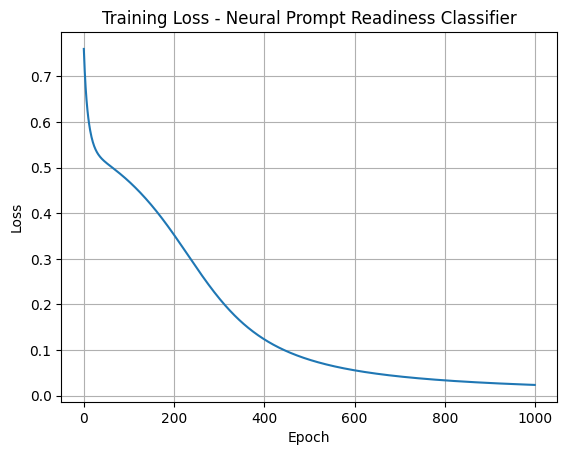

In [1]:
import numpy as np

# --- Features from Task 6 ---
X = np.array([
    [5, 1, 1],   # "Write a poem about love"
    [1, 1, 1],   # "Explain"
    [7, 4, 1],   # "Generate Python code to train a CNN"
    [5, 1, 1]    # "Summarize the latest news"
])

# Labels: 1 = Valid/Ready, 0 = Incomplete
y_true = np.array([[1], [0], [1], [1]])

# --- ANN Hyperparameters ---
input_size = X.shape[1]  # 3 features
hidden_size = 4
output_size = 1
learning_rate = 0.1
epochs = 1000

# --- Weight initialization ---
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros(output_size)

# --- Activation functions ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# --- Binary Cross-Entropy Loss ---
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(loss)

# --- Training Loop ---
loss_history = []
for epoch in range(epochs):
    # Forward Pass
    Z1 = X.dot(W1) + b1
    A1 = sigmoid(Z1)
    Z2 = A1.dot(W2) + b2
    y_pred = sigmoid(Z2)
    
    # Compute Loss
    loss = binary_cross_entropy(y_true, y_pred)
    loss_history.append(loss)
    
    # Backpropagation
    dZ2 = y_pred - y_true
    dW2 = A1.T.dot(dZ2) / X.shape[0]
    db2 = np.mean(dZ2, axis=0)
    
    dA1 = dZ2.dot(W2.T)
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = X.T.dot(dZ1) / X.shape[0]
    db1 = np.mean(dZ1, axis=0)
    
    # Update parameters
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

# --- Predictions ---
Z1 = X.dot(W1) + b1
A1 = sigmoid(Z1)
Z2 = A1.dot(W2) + b2
y_pred = sigmoid(Z2)

# Classify: 1 = Valid, 0 = Incomplete
y_class = (y_pred >= 0.5).astype(int)

print("Predicted probabilities:\n", y_pred)
print("\nPredicted classes (0=Incomplete, 1=Valid):\n", y_class)

# Optional: Plot loss over epochs
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss - Neural Prompt Readiness Classifier")
plt.grid(True)
plt.show()


## Task 8: Evaluation

In [3]:
import numpy as np

# --- Predicted classes from Task 7 ---
y_class = np.array([[1], [0], [1], [1]])
y_true = np.array([[1], [0], [1], [1]])

# --- Accuracy ---
accuracy = np.mean(y_class == y_true)
print("Accuracy:", accuracy)

# --- Confusion Matrix (optional) ---
# Rows = true labels, Columns = predicted labels
# [[TP, FP],
#  [FN, TN]]
TP = np.sum((y_true == 1) & (y_class == 1))
TN = np.sum((y_true == 0) & (y_class == 0))
FP = np.sum((y_true == 0) & (y_class == 1))
FN = np.sum((y_true == 1) & (y_class == 0))

confusion_matrix = np.array([[TP, FP],
                             [FN, TN]])

print("Confusion Matrix:\n", confusion_matrix)


Accuracy: 1.0
Confusion Matrix:
 [[3 0]
 [0 1]]
